# Exercise 7.2c solution

**Note:** Because we implemented `V_target` as an independent Python function in the first step, we can simply call it from inside our `rhs` function!

We just "pass along" the time argument `t`, which the `rhs` function already receives as its first argument for `solve_ivp` to work. You could, of course, alternatively define the `V_target` logic directly inside the `rhs` function itself—but then we would lose the ability to easily plot it out beforehand for visual comparison.


In [ ]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt


def V_target(t):
    return -80 + 40 * (t > 2) * (t < 6)


# ----------------------------------------------

In [2]:
from scipy.integrate import solve_ivp


def rhs(t, V, Cm, Rs):
    dV_dt = (V_target(t) - V) / (Cm * Rs)
    return dV_dt

In [3]:
# Define time array
time = (0, 10)

# Define parameters
Cm = 0.05  # nF
Rs = 10  # MOhm
params = (Cm, Rs)

# Define initial condition
y0 = (-80,)

# Call solve_ivp
solution = solve_ivp(rhs, time, y0, args=params, max_step=0.1)

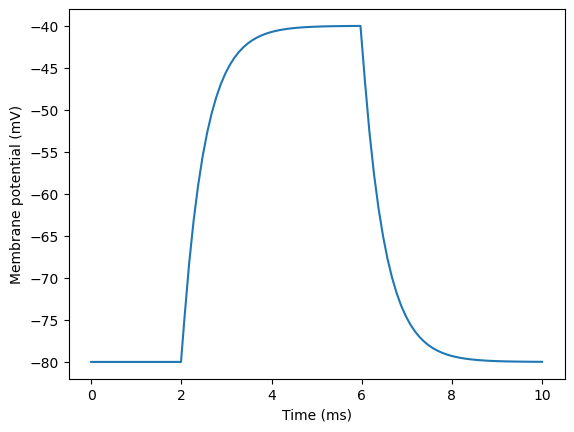

In [4]:
# Plot solution
t = solution.t
(V,) = solution.y

plt.plot(t, V)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.show()